In [2]:
import pandas as pd
from toric_spines_sim.paths import get_data_path

data = pd.read_csv(get_data_path("toric_spines_properties_imputed.csv"))
data

,RMP (mV),Resistance (GΩ),Time constant (s),Capacitance (nF),Threshold (mV),Peak (mV),Threshold to peak (mV),Spike width (ms),Latency (ms),Cell
0,-60.7,0.290000,0.060000,0.190000,-39.1,18.8,57.9,0.6,5.4,M203a
1,-66.3,0.180000,0.060000,0.320000,-44.5,18.4,62.9,0.5,6.2,M203b
2,-63.5,0.060000,0.062076,0.545510,-42.1,10.6,52.7,0.4,70.9,M203c
3,-72.6,0.580000,0.060000,0.100000,-38.6,28.6,67.2,0.8,12.3,M203e
4,-66.6,0.860000,0.090000,0.100000,-37.0,32.0,69.0,1.2,7.7,M204d
5,-67.0,0.690000,0.070000,0.100000,-33.0,26.4,59.4,1.3,4.1,M204e
6,-56.2,0.332694,0.080000,0.090000,-34.5,33.0,67.5,1.2,10.4,M204f
7,-62.9,0.290000,0.060000,0.220000,-40.9,36.6,77.5,0.5,30.3,M204h
8,-62.6,0.244592,0.060000,0.150000,-35.3,31.1,66.4,0.5,65.4,M204i
9,-62.0,0.310000,0.070000,0.240000,-31.7,29.2,60.9,1.1,63.3,M205h


In [3]:
# print average values

data["RMP (mV)"].mean()

np.float64(-65.65)

In [4]:
import numpy as np
avg_area = 1895 + 500 # um^2
cm_nF_per_um2 = np.array(data["Capacitance (nF)"])/avg_area
# 1 nf/um^2 = 10^3 F/m^2 = 10^5 uF/cm^2
cm_uF_per_cm2 = cm_nF_per_um2 * 10**5
print(cm_uF_per_cm2)
print(f"c_m (uF/cm^2)= {np.median(cm_uF_per_cm2):0.3f} +/- {np.std(cm_uF_per_cm2):0.3f}")

[  7.93319415  13.3611691   22.77701529   4.17536534   4.17536534
   4.17536534   3.75782881   9.18580376   6.26304802  10.02087683
  23.8760145   24.217119     3.34029228   7.51565762  18.78914405
   5.42797495  69.72860125  18.37160752   3.75782881 229.22755741]
c_m (uF/cm^2)= 8.559 +/- 49.197


In [5]:
rho_m_Gohm_um2 = np.array(data["Resistance (GΩ)"])*avg_area
# 1 Gohm*um^2 = 10 ohm*cm^2
rho_m_ohm_cm2 = rho_m_Gohm_um2 * 10
g_pas_S_per_cm2 = 1/rho_m_ohm_cm2
print(g_pas_S_per_cm2)
print(f"g_pas (S/cm^2)= {np.median(g_pas_S_per_cm2):0.6f} +/- {np.std(g_pas_S_per_cm2):0.6f}")

[1.43978115e-04 2.31964741e-04 6.95894224e-04 7.19890577e-05
 4.85507598e-05 6.05125412e-05 1.25501484e-04 1.43978115e-04
 1.70707285e-04 1.34689205e-04 1.38976235e-04 3.79578668e-04
 1.28690399e-04 1.22804863e-04 2.45609726e-04 1.48912899e-04
 4.17536534e-04 3.21181950e-04 1.24362947e-04 5.96480763e-04]
g_pas (S/cm^2)= 0.000144 +/- 0.000172


In [6]:
tau_m_ms = np.array(data["Capacitance (nF)"]) * np.array(data["Resistance (GΩ)"]) * 1000
print(tau_m_ms)
print(f"tau_m (ms)= {np.median(tau_m_ms):0.3f} +/- {np.std(tau_m_ms):0.3f}")


[ 55.1         57.6         32.73057097  58.          86.
  69.          29.94250498  63.8         36.68881509  74.4
 171.79926061  63.8         25.95603326  61.2         76.5
  36.4506701  167.          57.2         30.21662719 384.3       ]
tau_m (ms)= 59.600 +/- 79.259


[ 60.          60.          62.07569834  60.          90.
  70.          80.          60.          60.          70.
  80.41150314  60.          60.          60.          70.
  60.         160.          60.          70.         270.        ]
time constant (s) from Sanculi 61.037849171112796 +/- 48.629294778576494


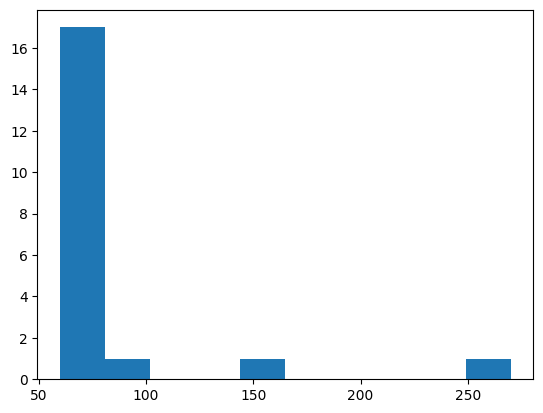

In [7]:
print(np.array(data["Time constant (s)"] * 1000))
print("time constant (s) from Sanculi", np.median(np.array(data["Time constant (s)"]) * 1000), "+/-", np.std(np.array(data["Time constant (s)"]) * 1000))
# print("difference", np.array(data["Time constant (s)"]) * 1000 - tau_m_ms)

import matplotlib.pyplot as plt

plt.hist(np.array(data["Time constant (s)"]) * 1000, bins=10)
plt.show()




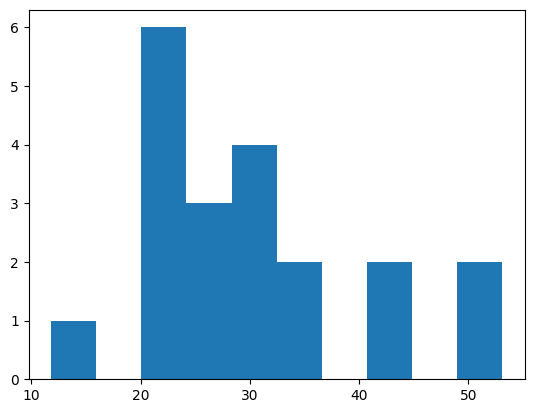

[21.6 21.8 21.4 34.  29.6 34.  21.7 22.  27.3 30.3 31.  41.6 27.  28.
 53.1 21.9 43.2 49.5 28.7 11.8]


In [11]:
ext = np.array(data["Threshold (mV)"]) - np.array(data["RMP (mV)"]) 
plt.hist(ext, bins=10)
plt.show()
print(ext)


